# S1c — Clustering de Regimes Operacionais (V1)

**Acelerado por GPU (RTX 5070) + CPU paralelo (24 cores)**

**Objetivo:** Identificar regimes operacionais distintos no circuito de moagem
usando algoritmos de clustering não-supervisionado. Esta é a versão base (v1),
que utiliza todas as variáveis disponíveis sem pré-processamento adicional além
da limpeza realizada no notebook S1a.

**Entrada:** `dados_limpos` (banco PostgreSQL)

**Saídas:**
- `s1c_v1_metricas_clustering` — métricas de validação por algoritmo/k
- `s1c_v1_regimes` — caracterização dos regimes identificados
- `s1c_v1_regime_centroides` — centroides dos regimes por variável
- `dados_com_clusters_v1.parquet` — dados limpos + coluna regime (parquet local)
- Figuras salvas com prefixo `S1c_v1_` (stage=s1c_v1)

**Etapas:**
1. Carga e preparação dos dados
2. Normalização (StandardScaler)
3. Avaliação: KMeans (GPU) + DBSCAN (CPU) + GMM (CPU paralelo) para k=2..8
4. Seleção do melhor modelo (maior Silhouette)
5. Caracterização dos regimes
6. Visualizações (métricas, PCA, TPH, radar, temporal, heatmap)
7. Salvamento (parquet local + imagens no banco)

## 0 - Setup: Caminhos e Imports do Projeto

**Objetivo:** Configurar o ambiente de execução com caminhos padronizados, importar bibliotecas
do projeto (incluindo `db_utils` para persistência no banco PostgreSQL) e definir constantes
do pipeline de clustering.

**Parâmetros:**
- `STAGE = "s1c_v1"`: identificador da sprint/versão para nomeação de tabelas e figuras no banco
- `K_RANGE = range(2, 9)`: faixa de k testada (2 a 8 clusters) — cobre desde a separação mínima até granularidade razoável sem overfitting
- `DEVICE = cuda/cpu`: usa GPU (RTX 5070) se disponível para acelerar KMeans e PCA via PyTorch

**Justificativa:** O bloco de setup centraliza todos os caminhos e imports, garantindo que o
notebook funcione independente do diretório de execução. A conexão com o banco via `db_utils`
permite persistir resultados para consumo pelo dashboard e rastreabilidade entre versões.

In [8]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, os, time
from pathlib import Path

# Raiz do projeto — resolve independente de onde o notebook é executado
PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "01_sprint1" / "clustering_v1"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

# Adicionar diretório de scripts ao path (para importar db_utils, etc.)
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Garantir que os diretórios de saída existem
for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# Imports de bibliotecas
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed

# ── Importar módulos do projeto (db_utils) ──
from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas

# Criar tabelas no banco se não existirem
criar_tabelas()

# ==============================================================================
# Configurações de visualização e constantes
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.max_open_warning"] = 50

STAGE = "s1c_v1"                # Identificador da sprint para tabelas e figuras
K_RANGE = range(2, 9)        # Faixa de clusters a avaliar (2 a 8)
N_CPU = -1                    # Usar todos os cores disponíveis (loky fix)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  S1c — CLUSTERING DE REGIMES OPERACIONAIS (V1)")
print("  Stage: s1c_v1 | Conectado ao banco PostgreSQL")
print("=" * 60)
print(f"  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"  CPU cores: {os.cpu_count()}")
print(f"  Device: {DEVICE}")
print("=" * 60)

t0 = time.time()

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
  S1c — CLUSTERING DE REGIMES OPERACIONAIS (V1)
  Stage: s1c_v1 | Conectado ao banco PostgreSQL
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU
  CPU cores: 24
  Device: cuda


## 1 - Carga dos Dados

**Objetivo:** Carregar o dataset limpo (`dados_limpos`) do banco PostgreSQL via `carregar_dados()`
e preparar as colunas de processo para o pipeline de clustering.

**Parâmetros:**
- Tabela de entrada: `dados_limpos` (saída do notebook S1a — Preparação de Dados)
- `col_tph`: coluna da balança de alimentação, identificada automaticamente para caracterização dos regimes
- `nome_curto()`: função auxiliar que remove sufixos de tag PI e prefixos numéricos para visualizações legíveis

**Justificativa:** Os dados já passaram por limpeza (remoção de duplicatas, tratamento de outliers IQR,
imputação de NaN) no notebook S1a. A função `carregar_dados()` do `db_utils` garante que os dados
venham diretamente do banco PostgreSQL, mantendo consistência com o pipeline principal.

**Saída esperada:** DataFrame com ~632k registros x 26 variáveis de processo, indexado por Timestamp.

In [9]:
# Carregar dados limpos do banco PostgreSQL (saída do notebook S1a — Preparação de Dados)
# Os dados já passaram por limpeza, tratamento de outliers e remoção de duplicatas
df = carregar_dados("dados_limpos")
df = df.drop(columns=["id"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# Separar colunas de processo (excluir Timestamp que virou índice)
COLS_PROCESSO = [c for c in df.columns if c != "Timestamp"]

# Função auxiliar para nomes curtos nas visualizações
import re
def nome_curto(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

NOMES_CURTOS = {c: nome_curto(c) for c in COLS_PROCESSO}

# Identificar coluna de TPH (balança de alimentação) para caracterização dos regimes
_cols_tph = [c for c in COLS_PROCESSO if "BALANÇA" in c.upper()]
if not _cols_tph:
    raise ValueError("Nenhuma coluna com 'BALANÇA' encontrada. Verifique os dados de entrada.")
col_tph = _cols_tph[0]

print(f"Dataset: {df.shape[0]:,} registros x {df.shape[1]} variaveis")
print(f"Periodo: {df.index.min()} a {df.index.max()}")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_limpos
Dataset: 632,985 registros x 27 variaveis
Periodo: 2024-08-01 00:00:00 a 2026-03-01 00:00:00


## 2 - Preparação e Normalização

**Objetivo:** Tratar valores ausentes residuais, normalizar os dados com StandardScaler (z-score)
e transferir para a GPU (tensor PyTorch) para processamento acelerado nos algoritmos de clustering.

**Parâmetros:**
- Limiar de exclusão: `>50% NaN` — colunas com mais da metade de valores ausentes são descartadas
- `StandardScaler`: normalização z-score (média=0, std=1) para que variáveis com escalas diferentes não dominem o clustering

**Justificativa:** Algoritmos de clustering baseados em distância (KMeans, DBSCAN, GMM) são sensíveis
à escala das variáveis. A normalização z-score garante contribuição equitativa de cada feature ao
cálculo de distâncias. O StandardScaler é a escolha padrão, embora seja sensível a outliers —
limitação que será endereçada na versão v2 com RobustScaler.

**Entrada:** DataFrame com ~632k registros x 26 variáveis de processo
**Saída:** Matriz normalizada (numpy) + tensor GPU (PyTorch float32)

In [10]:
# Verificar colunas com excesso de valores ausentes (>50%)
# Colunas com mais da metade dos valores faltantes não contribuem para o clustering
nan_pct = df[COLS_PROCESSO].isnull().mean()
cols_excluir = nan_pct[nan_pct > 0.5].index.tolist()
if cols_excluir:
    print(f"\nColunas excluidas (>50% NaN): {cols_excluir}")
    COLS_CLUSTER = [c for c in COLS_PROCESSO if c not in cols_excluir]
else:
    COLS_CLUSTER = COLS_PROCESSO.copy()

if not COLS_CLUSTER:
    raise ValueError("Nenhuma coluna restante após filtro de NaN >50%. Verifique os dados de entrada.")

# Remover linhas com NaN restantes para obter matriz completa
# O clustering requer uma matriz sem valores ausentes
df_clean = df[COLS_CLUSTER].dropna()

if len(df_clean) < 100:
    raise ValueError(f"Apenas {len(df_clean)} registros após dropna — insuficiente para clustering.")

print(f"Registros para clustering: {len(df_clean):,} ({100*len(df_clean)/len(df):.1f}%)")

# Normalização z-score (média=0, desvio=1)
# Garante que cada variável contribua proporcionalmente ao cálculo de distâncias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Transferir dados para GPU (tensor PyTorch float32) para KMeans e PCA acelerados
# A GPU permite cálculo vetorizado de distâncias com torch.cdist
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)
print(f"Dados na GPU: {X_tensor.shape} ({X_tensor.element_size() * X_tensor.nelement() / 1e6:.0f} MB)")


Colunas excluidas (>50% NaN): ['1025_RETOMADA_SL01_NIVEL_pipoint']
Registros para clustering: 632,985 (100.0%)
Dados na GPU: torch.Size([632985, 26]) (66 MB)


## 2.1 - Implementação KMeans na GPU (PyTorch)

**Objetivo:** Implementar KMeans usando operações tensoriais do PyTorch para execução na GPU, evitando transferências CPU↔GPU.

**Parâmetros:**
- `max_iter = 300`: limite de iterações por inicialização — padrão do sklearn
- `n_init = 10`: número de inicializações aleatórias — seleciona a de menor inércia
- Convergência: `shift < 1e-6` — para quando centroides param de se mover

**Justificativa:** O sklearn KMeans não suporta GPU. A implementação via PyTorch usa `torch.cdist` para cálculo vetorizado de distâncias, aproveitando a RTX 5070 para ~800k registros.

In [11]:
# GPU KMeans — implementacao PyTorch
def kmeans_gpu(X: torch.Tensor, k: int, max_iter: int = 300, n_init: int = 10, seed: int = 42):
    """KMeans completo na GPU via PyTorch. Retorna labels e inertia."""
    n, d = X.shape
    best_labels = None
    best_inertia = float("inf")

    for init_i in range(n_init):
        rng = torch.Generator(device=X.device).manual_seed(seed + init_i)
        idx = torch.randperm(n, generator=rng, device=X.device)[:k]
        centers = X[idx].clone()

        for _ in range(max_iter):
            # Distancias ao quadrado (broadcasting eficiente)
            dists = torch.cdist(X, centers, p=2.0)
            labels = dists.argmin(dim=1)

            # Atualizar centroides
            new_centers = torch.zeros_like(centers)
            counts = torch.zeros(k, device=X.device)
            for j in range(k):
                mask = labels == j
                if mask.any():
                    new_centers[j] = X[mask].mean(dim=0)
                    counts[j] = mask.sum()
                else:
                    new_centers[j] = X[torch.randint(n, (1,), device=X.device)]

            # Convergencia
            shift = (new_centers - centers).norm()
            centers = new_centers
            if shift < 1e-6:
                break

        # Inertia
        dists_final = torch.cdist(X, centers, p=2.0)
        min_dists = dists_final.min(dim=1).values
        inertia = (min_dists ** 2).sum().item()

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.cpu().numpy()
            best_centers = centers.cpu().numpy()

    return best_labels, best_inertia, best_centers

## 2.2 - Implementação PCA na GPU (PyTorch SVD)

**Objetivo:** Reduzir dimensionalidade via PCA usando decomposição SVD na GPU para visualização 2D dos clusters.

**Parâmetros:**
- `n_components = 2`: projeção em 2 dimensões para scatter plot

**Justificativa:** PCA via SVD na GPU é mais rápido que o sklearn para datasets grandes. A variância explicada por PC1+PC2 indica a qualidade da representação 2D.

In [12]:
# PCA via decomposição SVD na GPU
def pca_gpu(X: torch.Tensor, n_components: int = 2):
    """Redução de dimensionalidade via SVD na GPU.
    Retorna: projeções (numpy), variância explicada por componente (numpy)."""
    X_centered = X - X.mean(dim=0)        # Centralizar dados (média zero)
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)
    components = Vt[:n_components]          # Componentes principais
    X_proj = X_centered @ components.T      # Projetar dados
    var_total = (S ** 2).sum()
    var_explained = (S[:n_components] ** 2) / var_total  # Proporção da variância
    return X_proj.cpu().numpy(), var_explained.cpu().numpy()

## 3 - Avaliação de Algoritmos de Clustering

**Objetivo:** Executar KMeans (GPU), DBSCAN (CPU) e GMM (CPU paralelo) para k=2..8 e calcular métricas de validação interna para cada combinação.

**Parâmetros:**
- `K_RANGE = 2..8`: faixa de clusters avaliada (KMeans e GMM)
- KMeans: `n_init=10` inicializações, implementação GPU via PyTorch
- DBSCAN: `eps` estimado via k-distance graph (k=2×dimensões), `min_samples=2×dimensões` — clusters de forma arbitrária com detecção de ruído
- GMM: `covariance_type="full"`, `n_init=3`, `max_iter=200` — clusters com formas elípticas arbitrárias
- Métricas: Silhouette (coesão vs separação), Davies-Bouldin (dispersão intra/inter), Calinski-Harabasz (variância inter/intra)
- `sample_size=50000` para Silhouette: amostragem para viabilizar cálculo em datasets grandes

**Justificativa:** Comparar três algoritmos com premissas diferentes — KMeans (clusters esféricos), DBSCAN (clusters de forma arbitrária com detecção de ruído) e GMM (clusters elípticos) — permite identificar qual captura melhor a estrutura dos dados industriais.

In [13]:
# ============================================================
# 3a. KMeans na GPU — varrer k de 2 a 8
# ============================================================
print("\n--- Avaliando KMeans (GPU) ---")
resultados = []

for k in K_RANGE:
    t1 = time.time()
    labels, inertia, centers = kmeans_gpu(X_tensor, k)

    # Métricas de validação interna (calculadas na CPU em paralelo)
    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "KMeans",
        "n_clusters": k,
        "silhouette": round(sil, 4),
        "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1),
        "inertia": round(inertia, 1),
        "bic": None,
        "selecionado": False,
        "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  ({dt:.1f}s)")




--- Avaliando KMeans (GPU) ---
  k=2: 2 clusters  Sil=0.1608  DB=2.1965  CH=122691  (13.0s)
  k=3: 3 clusters  Sil=0.1422  DB=2.1774  CH=101027  (14.6s)
  k=4: 4 clusters  Sil=0.1346  DB=2.2538  CH=87168  (14.2s)
  k=5: 5 clusters  Sil=0.1384  DB=2.1778  CH=80921  (15.4s)
  k=6: 6 clusters  Sil=0.1407  DB=2.1688  CH=73108  (15.1s)
  k=7: 7 clusters  Sil=0.1439  DB=2.0589  CH=67191  (16.3s)
  k=8: 8 clusters  Sil=0.1428  DB=2.1154  CH=62415  (14.0s)


In [14]:
# ============================================================
# 3b. DBSCAN — sweep sistemático de eps × min_samples (dataset completo)
# ============================================================
print("\n--- Avaliando DBSCAN (sweep sistemático, dataset completo) ---")

DBSCAN_MIN_SAMPLES_LIST = [6, 8, 10, 12]

# NearestNeighbors no dataset completo
nn = NearestNeighbors(n_neighbors=max(DBSCAN_MIN_SAMPLES_LIST), n_jobs=N_CPU)
nn.fit(X_scaled)
distances_all, _ = nn.kneighbors(X_scaled)

# Detecção de cotovelo via distância perpendicular máxima (método geométrico)
def knee_perpendicular(k_dists):
    """Encontra o ponto de cotovelo pela máxima distância perpendicular à reta endpoints."""
    y = np.sort(k_dists)
    n = len(y)
    x = np.arange(n)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / line_len
    points = np.column_stack([x, y])
    vecs = points - p1
    proj = np.dot(vecs, line_unit)[:, None] * line_unit
    perp = vecs - proj
    dists = np.linalg.norm(perp, axis=1)
    knee_idx = np.argmax(dists)
    return float(y[knee_idx])

# Estimar eps_centro usando min_samples mediano
k_ref = DBSCAN_MIN_SAMPLES_LIST[len(DBSCAN_MIN_SAMPLES_LIST) // 2]
k_dists_ref = distances_all[:, k_ref - 1]
eps_centro = knee_perpendicular(k_dists_ref)
print(f"  eps_centro (knee, k={k_ref}): {eps_centro:.4f}")

# Gerar faixa de eps: 50% a 100% do centro, em steps de 5%
eps_range = np.arange(0.50, 1.05, 0.05) * eps_centro
print(f"  eps_range: {eps_range.min():.4f} a {eps_range.max():.4f} ({len(eps_range)} valores)")
print(f"  min_samples: {DBSCAN_MIN_SAMPLES_LIST}")
print(f"  Dataset: {len(X_scaled):,} registros (100%)")

# Sweep: testar cada combinação
dbscan_results = []
for ms in DBSCAN_MIN_SAMPLES_LIST:
    for eps_val in eps_range:
        t1 = time.time()
        dbscan = DBSCAN(eps=eps_val, min_samples=ms, n_jobs=N_CPU)
        labels_db = dbscan.fit_predict(X_scaled)

        n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        pct_noise = 100 * n_noise / len(labels_db)
        dt = time.time() - t1

        sil_val = None
        mask_valid = labels_db != -1
        if n_clusters_db >= 2 and mask_valid.sum() > n_clusters_db:
            sil_val = silhouette_score(
                X_scaled[mask_valid], labels_db[mask_valid],
                sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU
            )
        selecionavel = 2 <= n_clusters_db <= max(K_RANGE) and pct_noise < 50 and sil_val is not None

        dbscan_results.append({
            "eps": round(eps_val, 4), "min_samples": ms,
            "n_clusters": n_clusters_db, "pct_noise": round(pct_noise, 1),
            "silhouette": round(sil_val, 4) if sil_val is not None else None,
            "selecionavel": selecionavel,
            "_labels": labels_db,
        })
        status = "OK" if selecionavel else "descartado"
        sil_str = f"{sil_val:.4f}" if sil_val is not None else "  -   "
        print(f"  eps={eps_val:.4f} ms={ms:2d}: {n_clusters_db:>5} clusters  noise={pct_noise:5.1f}%  Sil={sil_str}  [{status}]  ({dt:.1f}s)")

# Selecionar melhor DBSCAN (maior Silhouette com >=2 clusters)
dbscan_valid = [r for r in dbscan_results if r.get("selecionavel", False)]
print(f"\n  Combinações testadas: {len(dbscan_results)} | válidas: {len(dbscan_valid)}")

if dbscan_valid:
    best_db = max(dbscan_valid, key=lambda x: x["silhouette"])
    print(f"  Melhor DBSCAN: eps={best_db['eps']}, ms={best_db['min_samples']}, "
          f"k={best_db['n_clusters']}, Sil={best_db['silhouette']:.4f}, noise={best_db['pct_noise']:.1f}%")

    labels_dbscan_full = best_db["_labels"]

    # Métricas no dataset completo (excluindo ruído)
    mask_valid = labels_dbscan_full != -1
    sil_full = silhouette_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid],
                                 sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU)
    db_full = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])
    ch_full = calinski_harabasz_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])

    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": best_db["n_clusters"],
        "silhouette": round(sil_full, 4), "davies_bouldin": round(db_full, 4),
        "calinski_harabasz": round(ch_full, 1), "inertia": None,
        "bic": None, "selecionado": False, "_labels": labels_dbscan_full,
    })
    print(f"  DBSCAN (full): Sil={sil_full:.4f}  DB={db_full:.4f}  CH={ch_full:.0f}")
else:
    print("  DBSCAN: nenhuma combinação válida encontrada")
    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": 0,
        "silhouette": None, "davies_bouldin": None,
        "calinski_harabasz": None, "inertia": None,
        "bic": None, "selecionado": False, "_labels": None,
    })




--- Avaliando DBSCAN (sweep sistemático, dataset completo) ---
  eps_centro (knee, k=10): 2.0889
  eps_range: 1.0445 a 2.0889 (11 valores)
  min_samples: [6, 8, 10, 12]
  Dataset: 632,985 registros (100%)
  eps=1.0445 ms= 6:  9667 clusters  noise= 19.6%  Sil=0.1460  [descartado]  (70.7s)
  eps=1.1489 ms= 6:  8194 clusters  noise= 14.4%  Sil=0.1001  [descartado]  (69.5s)
  eps=1.2533 ms= 6:  6832 clusters  noise= 10.9%  Sil=0.0419  [descartado]  (74.6s)
  eps=1.3578 ms= 6:  5513 clusters  noise=  8.4%  Sil=-0.0192  [descartado]  (71.2s)
  eps=1.4622 ms= 6:  4436 clusters  noise=  6.6%  Sil=-0.1109  [descartado]  (71.3s)
  eps=1.5667 ms= 6:  3487 clusters  noise=  5.2%  Sil=-0.1811  [descartado]  (70.8s)
  eps=1.6711 ms= 6:  2664 clusters  noise=  4.2%  Sil=-0.2195  [descartado]  (73.5s)
  eps=1.7756 ms= 6:  1993 clusters  noise=  3.3%  Sil=-0.2552  [descartado]  (69.8s)
  eps=1.8800 ms= 6:  1482 clusters  noise=  2.7%  Sil=-0.2643  [descartado]  (70.2s)
  eps=1.9845 ms= 6:  1126 cluste

In [15]:
# ============================================================
# 3c. GMM na CPU paralela — varrer k de 2 a 8
# ============================================================
print(f"\n--- Avaliando GMM (CPU paralelo, {os.cpu_count()} cores) ---")
for k in K_RANGE:
    t1 = time.time()
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           n_init=3, max_iter=200, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    # Métricas de validação interna
    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "GMM",
        "n_clusters": k,
        "silhouette": round(sil, 4),
        "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1),
        "inertia": None,
        "bic": round(bic, 1),
        "selecionado": False,
        "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  BIC={bic:.0f}  ({dt:.1f}s)")


--- Avaliando GMM (CPU paralelo, 24 cores) ---
  k=2: 2 clusters  Sil=0.1580  DB=2.2305  CH=119867  BIC=34585611  (24.2s)
  k=3: 3 clusters  Sil=0.1375  DB=2.2294  CH=96664  BIC=30371405  (34.7s)
  k=4: 4 clusters  Sil=0.1152  DB=2.4629  CH=77457  BIC=28525156  (88.4s)
  k=5: 5 clusters  Sil=0.1170  DB=2.3572  CH=72507  BIC=27329876  (159.4s)
  k=6: 6 clusters  Sil=0.1182  DB=2.3956  CH=65372  BIC=24568160  (135.8s)
  k=7: 7 clusters  Sil=0.1005  DB=2.3936  CH=58111  BIC=24947924  (167.4s)
  k=8: 8 clusters  Sil=0.1193  DB=2.2521  CH=57260  BIC=23027157  (217.9s)


## 4 - Seleção do Melhor Modelo

**Objetivo:** Selecionar automaticamente a combinação algoritmo/k com maior Silhouette Score dentre todas as avaliações.

**Parâmetros:**
- Critério de seleção: `argmax(silhouette)` — métrica que balanceia coesão intra-cluster e separação inter-cluster

**Justificativa:** O Silhouette Score é a métrica mais intuitiva e amplamente utilizada para validação interna de clustering, variando de -1 (atribuição errada) a +1 (clusters bem separados).

In [16]:
# Selecionar modelo com maior Silhouette Score (ignorar DBSCAN se descartado)
df_res = pd.DataFrame(resultados)
df_valid = df_res[df_res["silhouette"].notna()].copy()
idx_best = df_valid["silhouette"].idxmax()
best = resultados[idx_best]
best["selecionado"] = True

best_algo = best["algoritmo"]
best_k = best["n_clusters"]
best_labels = best["_labels"]

# ── Resumo claro do modelo selecionado ──
print("=" * 60)
print(f"  MODELO SELECIONADO: {best_algo} com k={best_k} clusters")
print("=" * 60)
print(f"  Silhouette:        {best['silhouette']:.4f}")
print(f"  Davies-Bouldin:    {best['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz: {best['calinski_harabasz']:.1f}")
print()

# Proporção de cada cluster no dataset
unique, counts = np.unique(best_labels[best_labels >= 0] if best_algo == "DBSCAN" else best_labels, return_counts=True)
total_valid = counts.sum()
print(f"  {'Cluster':<10} {'Amostras':>10} {'Proporção':>10}")
print(f"  {'-'*10} {'-'*10} {'-'*10}")
for cid, cnt in zip(unique, counts):
    print(f"  {'Regime '+str(int(cid)):<10} {cnt:>10,} {100*cnt/total_valid:>9.1f}%")
if best_algo == "DBSCAN":
    n_noise = (best_labels == -1).sum()
    print(f"  {'Ruído':<10} {n_noise:>10,} {100*n_noise/len(best_labels):>9.1f}%")
print(f"  {'TOTAL':<10} {len(best_labels):>10,}")
print()

# Exibir tabela comparativa (sem coluna _labels)
print("Tabela comparativa de todos os algoritmos:")
print(df_res.drop(columns=["_labels"]).to_string(index=False))

  MODELO SELECIONADO: KMeans com k=2 clusters
  Silhouette:        0.1608
  Davies-Bouldin:    2.1965
  Calinski-Harabasz: 122690.9

  Cluster      Amostras  Proporção
  ---------- ---------- ----------
  Regime 0      362,904      57.3%
  Regime 1      270,081      42.7%
  TOTAL         632,985

Tabela comparativa de todos os algoritmos:
algoritmo  n_clusters  silhouette  davies_bouldin  calinski_harabasz    inertia        bic  selecionado
   KMeans           2      0.1608          2.1965           122690.9 13785558.0        NaN        False
   KMeans           3      0.1422          2.1774           101026.9 12475358.0        NaN        False
   KMeans           4      0.1346          2.2538            87168.2 11646195.0        NaN        False
   KMeans           5      0.1384          2.1778            80921.0 10889234.0        NaN        False
   KMeans           6      0.1407          2.1688            73108.2 10432759.0        NaN        False
   KMeans           7      0.1439  

## 5 - Caracterização dos Regimes Operacionais

**Objetivo:** Atribuir os labels do melhor modelo aos dados e calcular estatísticas descritivas de cada regime (tamanho, percentual, TPH médio/desvio).

**Parâmetros:**
- `col_tph`: variável principal de produção (alimentação da balança) usada para diferenciar regimes de alta/baixa produção
- Centroides calculados nos valores originais (não normalizados) para interpretabilidade

**Justificativa:** A caracterização em termos de TPH permite associar cada regime a um perfil operacional compreensível pela equipe de processo (ex: regime de alta carga vs regime de baixa carga).

In [17]:
# Atribuir labels do melhor modelo ao dataset
df_clean_regime = df_clean.copy()
df_clean_regime["regime"] = best_labels

# Calcular estatísticas descritivas por regime
regimes_list = []
for regime_id in sorted(df_clean_regime["regime"].unique()):
    mask = df_clean_regime["regime"] == regime_id
    n = mask.sum()
    tph_vals = df_clean_regime.loc[mask, col_tph]
    regimes_list.append({
        "regime": int(regime_id),
        "n_samples": int(n),
        "percentual": round(100 * n / len(df_clean_regime), 2),
        "tph_medio": round(tph_vals.mean(), 2),
        "tph_std": round(tph_vals.std(), 2),
    })

df_regimes = pd.DataFrame(regimes_list)
print("\nRegimes identificados:")
print(df_regimes.to_string(index=False))

# Centroides em valores originais (não normalizados) — média de cada variável por regime
centroides_orig = df_clean_regime.groupby("regime")[COLS_CLUSTER].mean()

# Formato longo para salvar no banco (regime x variavel x valor)
centroides_list = []
for regime_id in centroides_orig.index:
    for col in COLS_CLUSTER:
        centroides_list.append({
            "regime": int(regime_id),
            "variavel": col,
            "valor_centroide": round(centroides_orig.loc[regime_id, col], 4),
        })
df_centroides = pd.DataFrame(centroides_list)


Regimes identificados:
 regime  n_samples  percentual  tph_medio  tph_std
      0     362904       57.33     241.23    33.56
      1     270081       42.67     286.20    36.45


## 6 - Visualizações

**Objetivo:** Gerar 6 figuras diagnósticas para análise dos clusters identificados, cobrindo
diferentes perspectivas de validação e interpretação dos regimes operacionais.

**Figuras geradas (prefixo `S1c_v1_`):**
1. **Métricas de validação por k** — evolução de Silhouette, Davies-Bouldin, Calinski-Harabasz
2. **Scatter PCA 2D** — projeção dos clusters nas 2 primeiras componentes principais (GPU)
3. **Distribuição de TPH** — histograma de densidade + boxplot da alimentação por regime
4. **Radar Chart** — perfil multivariado dos centroides (top 10 variáveis discriminantes)
5. **Série Temporal** — alternância de regimes ao longo do tempo (reamostrado por hora)
6. **Heatmap** — centroides normalizados em todas as variáveis de processo

**Justificativa:** As visualizações cobrem qualidade do clustering (métricas), separação
espacial (PCA), perfil de produção (TPH), assinatura multivariada (radar/heatmap) e
estabilidade temporal (série). Cada figura é salva localmente em `FIGURES_DIR` e no
banco PostgreSQL via `salvar_imagem()` para consumo pelo dashboard.

In [18]:
# Paleta de cores consistente para todos os gráficos de regimes
colors_regime = plt.cm.Set2(np.linspace(0, 1, best_k))

# Proteção: limitar legendas se houver muitos clusters (safety net)
MAX_LEGEND = 15
SHOW_LEGEND = best_k <= MAX_LEGEND

### 6.1 - Métricas de Validação por k

**Objetivo:** Visualizar a evolução das métricas (Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia/BIC) em função do número de clusters para KMeans, DBSCAN e GMM, com destaque no k selecionado.

[db_utils] Imagem 'metricas_clustering' salva para etapa s1c_v1


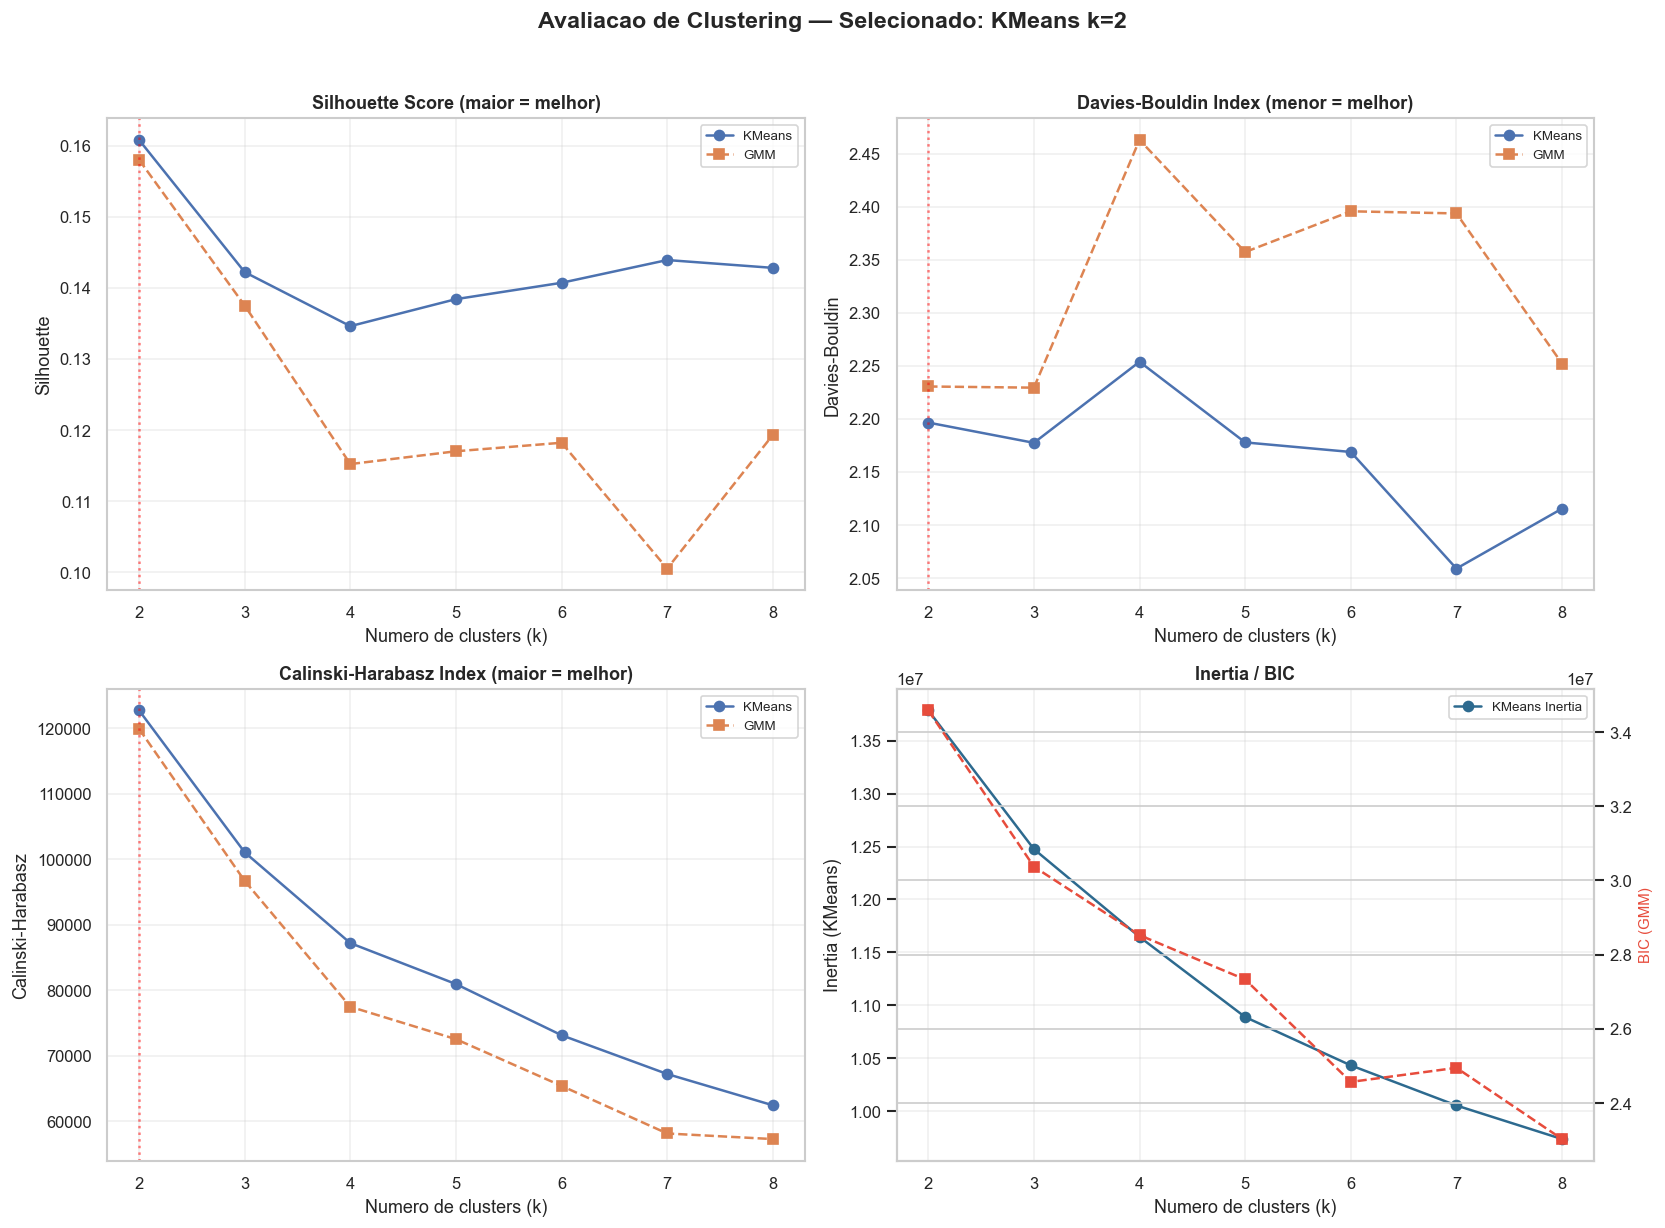

In [19]:
# --- 6.1 Métricas por k (Silhouette, DB, CH, Inertia/BIC) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plotar KMeans e GMM com marcadores distintos
for algo, marker, ls in [("KMeans", "o", "-"), ("GMM", "s", "--")]:
    subset = [r for r in resultados if r["algoritmo"] == algo]
    ks = [r["n_clusters"] for r in subset]
    axes[0, 0].plot(ks, [r["silhouette"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[0, 1].plot(ks, [r["davies_bouldin"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[1, 0].plot(ks, [r["calinski_harabasz"] for r in subset], marker=marker, ls=ls, label=algo)

# Plotar DBSCAN como ponto isolado (se teve métricas válidas)
dbscan_results = [r for r in resultados if r["algoritmo"] == "DBSCAN" and r["silhouette"] is not None]
if dbscan_results:
    db_r = dbscan_results[0]
    axes[0, 0].scatter([db_r["n_clusters"]], [db_r["silhouette"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")
    axes[0, 1].scatter([db_r["n_clusters"]], [db_r["davies_bouldin"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")
    axes[1, 0].scatter([db_r["n_clusters"]], [db_r["calinski_harabasz"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")

# Inertia (KMeans) e BIC (GMM) no mesmo subplot com eixo duplo
km_sub = [r for r in resultados if r["algoritmo"] == "KMeans"]
axes[1, 1].plot([r["n_clusters"] for r in km_sub], [r["inertia"] for r in km_sub],
                "o-", color="#2d6a8f", label="KMeans Inertia")
gmm_sub = [r for r in resultados if r["algoritmo"] == "GMM"]
ax_bic = axes[1, 1].twinx()
ax_bic.plot([r["n_clusters"] for r in gmm_sub], [r["bic"] for r in gmm_sub],
            "s--", color="#e74c3c", label="GMM BIC")
ax_bic.set_ylabel("BIC (GMM)", fontsize=9, color="#e74c3c")

# Formatação dos subplots
titles = ["Silhouette Score (maior = melhor)", "Davies-Bouldin Index (menor = melhor)",
          "Calinski-Harabasz Index (maior = melhor)", "Inertia / BIC"]
ylabels = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "Inertia (KMeans)"]
for i, ax in enumerate(axes.flatten()):
    ax.set_title(titles[i], fontweight="bold")
    ax.set_ylabel(ylabels[i])
    ax.set_xlabel("Numero de clusters (k)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Linha vertical no k selecionado
for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.axvline(best_k, color="red", linestyle=":", alpha=0.5)

fig.suptitle(f"Avaliacao de Clustering — Selecionado: {best_algo} k={best_k}",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_01_metricas_clustering.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "metricas_clustering", fig, "S1c_v1_01_metricas_clustering.png")
plt.show()

### 6.2 - Scatter PCA 2D

**Objetivo:** Projetar os dados em 2 componentes principais (GPU) e visualizar a separação dos clusters no espaço reduzido.

**Parâmetros:**
- `n_sample = 50000`: amostragem para legibilidade do scatter plot (evitar sobreposição excessiva)
- `alpha = 0.3`: transparência dos pontos para revelar densidade


PCA na GPU...
  Variancia PC1+PC2: 31.9%
[db_utils] Imagem 'pca_clusters' salva para etapa s1c_v1


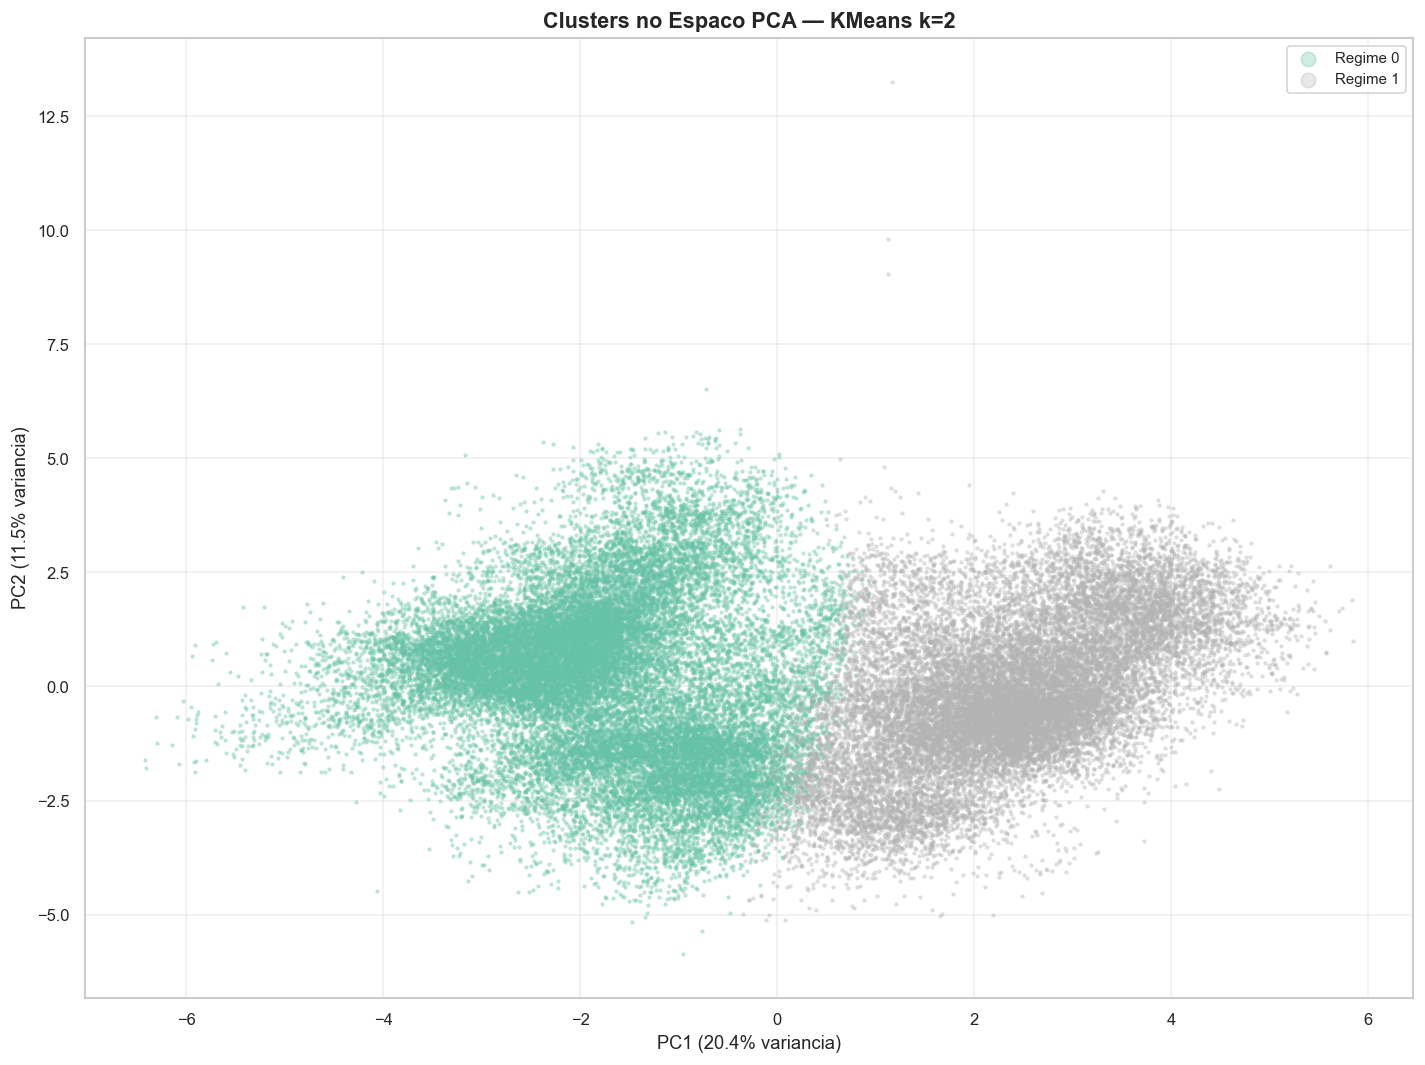

In [20]:
# --- 6.2 Scatter PCA 2D (projeção na GPU) ---
print("\nPCA na GPU...")
X_pca, var_explained = pca_gpu(X_tensor, n_components=2)
print(f"  Variancia PC1+PC2: {sum(var_explained[:2])*100:.1f}%")

# Amostragem para legibilidade do scatter
n_sample = min(50000, len(X_pca))
idx_sample = np.random.RandomState(42).choice(len(X_pca), n_sample, replace=False)

fig, ax = plt.subplots(figsize=(12, 9))
for rid in range(best_k):
    mask = best_labels[idx_sample] == rid
    ax.scatter(X_pca[idx_sample[mask], 0], X_pca[idx_sample[mask], 1],
               c=[colors_regime[rid]], s=3, alpha=0.3, label=f"Regime {rid}")
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variancia)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variancia)", fontsize=11)
ax.set_title(f"Clusters no Espaco PCA — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=9, markerscale=5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_02_pca_clusters.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "pca_clusters", fig, "S1c_v1_02_pca_clusters.png")
plt.show()

### 6.3 - Distribuição de TPH por Regime

**Objetivo:** Comparar a distribuição da variável de produção (TPH — alimentação da balança) entre regimes, usando histograma de densidade e boxplot lado a lado.

[db_utils] Imagem 'tph_por_regime' salva para etapa s1c_v1


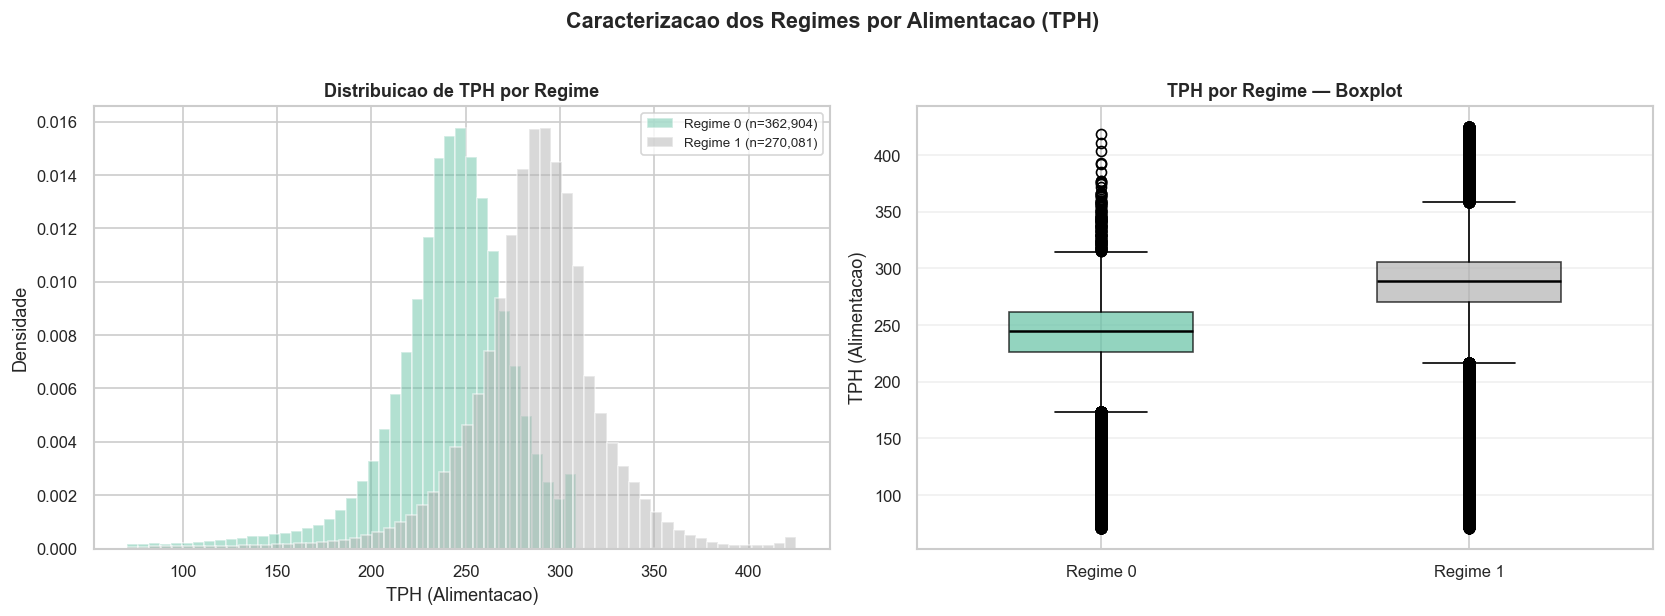

In [21]:
# --- 6.3 Distribuição de TPH por regime (histograma + boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de densidade
ax = axes[0]
for rid in range(best_k):
    mask = df_clean_regime["regime"] == rid
    ax.hist(df_clean_regime.loc[mask, col_tph], bins=60, alpha=0.5,
            color=colors_regime[rid], label=f"Regime {rid} (n={mask.sum():,})", density=True)
ax.set_xlabel("TPH (Alimentacao)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuicao de TPH por Regime", fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=8)

# Boxplot comparativo
ax = axes[1]
data_box = [df_clean_regime.loc[df_clean_regime["regime"] == r, col_tph].values for r in range(best_k)]
bp = ax.boxplot(data_box, labels=[f"Regime {r}" for r in range(best_k)], patch_artist=True, widths=0.5)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors_regime[i]); patch.set_alpha(0.7)
for m in bp["medians"]:
    m.set_color("black"); m.set_linewidth(1.5)
ax.set_ylabel("TPH (Alimentacao)")
ax.set_title("TPH por Regime — Boxplot", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Caracterizacao dos Regimes por Alimentacao (TPH)", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_03_tph_por_regime.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "tph_por_regime", fig, "S1c_v1_03_tph_por_regime.png")
plt.show()

### 6.4 - Radar Chart dos Centroides

**Objetivo:** Visualizar o perfil multivariado de cada regime usando as 10 variáveis mais discriminantes (maior desvio padrão entre centroides normalizados).

**Justificativa:** O radar chart permite comparar rapidamente as "assinaturas" operacionais de cada regime em múltiplas variáveis simultaneamente.

[db_utils] Imagem 'radar_centroides' salva para etapa s1c_v1


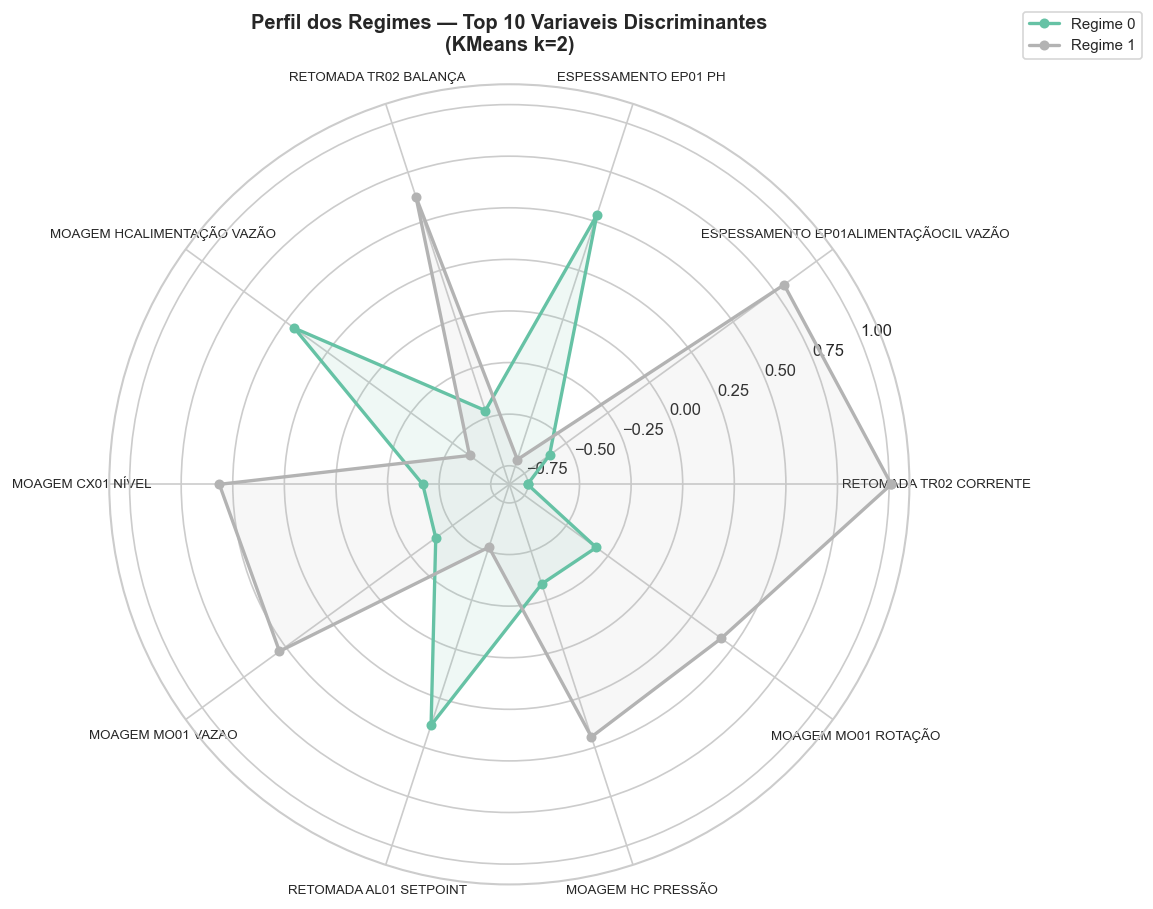

In [22]:
# --- 6.4 Radar chart dos centroides (top 10 variáveis discriminantes) ---

# Normalizar centroides para comparação justa no radar
centroides_norm = pd.DataFrame(scaler.transform(centroides_orig.values),
                                columns=COLS_CLUSTER, index=centroides_orig.index)

# Selecionar as 10 variáveis com maior discriminação entre regimes
var_disc = centroides_norm.std(axis=0).sort_values(ascending=False)
top_vars = var_disc.head(10).index.tolist()
labels_radar = [NOMES_CURTOS[v] for v in top_vars]

# Ângulos do radar (fechando o polígono)
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for rid in range(best_k):
    vals = centroides_norm.loc[rid, top_vars].values.tolist() + [centroides_norm.loc[rid, top_vars].values[0]]
    ax.plot(angles, vals, "o-", color=colors_regime[rid], linewidth=2, markersize=5, label=f"Regime {rid}")
    ax.fill(angles, vals, color=colors_regime[rid], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=8)
ax.set_title(f"Perfil dos Regimes — Top 10 Variaveis Discriminantes\n({best_algo} k={best_k})",
             fontsize=12, fontweight="bold", pad=20)
if SHOW_LEGEND: ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_04_radar_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "radar_centroides", fig, "S1c_v1_04_radar_centroides.png")
plt.show()

### 6.5 - Série Temporal dos Regimes

**Objetivo:** Visualizar a alternância de regimes ao longo do tempo, reamostrado por hora (moda do regime em cada hora).

**Justificativa:** Permite verificar se os regimes correspondem a padrões temporais reais (turnos, paradas, variações sazonais) e se há estabilidade ou oscilação excessiva.

[db_utils] Imagem 'serie_temporal_regimes' salva para etapa s1c_v1


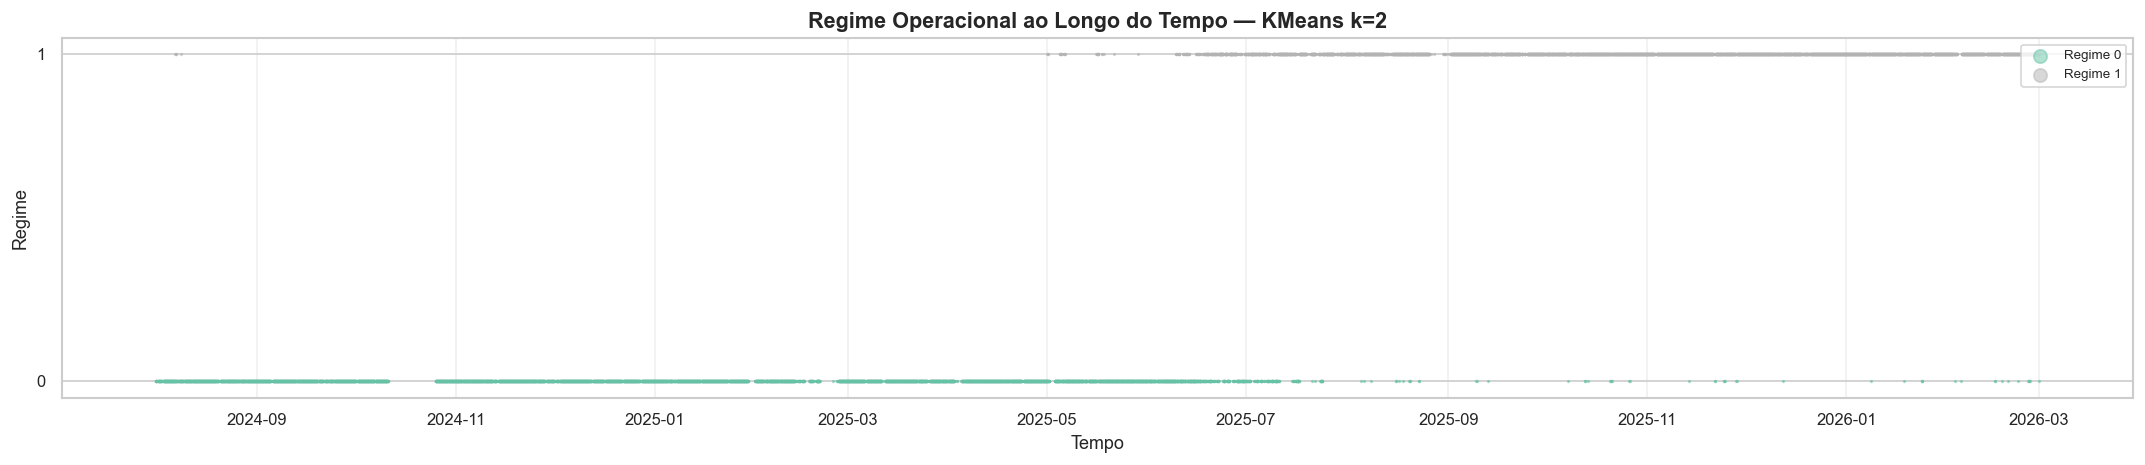

In [23]:
# --- 6.5 Série temporal dos regimes (reamostrado por hora) ---
df_ts = df_clean_regime[["regime"]].copy()

# Moda do regime em cada janela de 1 hora
regime_h = df_ts["regime"].resample("1h").agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan).dropna()

fig, ax = plt.subplots(figsize=(18, 4))
for rid in range(best_k):
    mask = regime_h == rid
    ax.scatter(regime_h.index[mask], regime_h[mask], c=[colors_regime[rid]], s=1, alpha=0.5, label=f"Regime {rid}")
ax.set_xlabel("Tempo"); ax.set_ylabel("Regime"); ax.set_yticks(range(best_k))
ax.set_title(f"Regime Operacional ao Longo do Tempo — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=8, markerscale=8, loc="upper right")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_05_serie_temporal_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "serie_temporal_regimes", fig, "S1c_v1_05_serie_temporal_regimes.png")
plt.show()

### 6.6 - Heatmap dos Centroides

**Objetivo:** Mostrar os centroides normalizados de todos os regimes em todas as variáveis de processo, permitindo identificar quais variáveis diferenciam cada regime.

**Justificativa:** O heatmap complementa o radar chart ao mostrar TODAS as variáveis (não só o top 10), facilitando a identificação de padrões sutis.

[db_utils] Imagem 'heatmap_centroides' salva para etapa s1c_v1


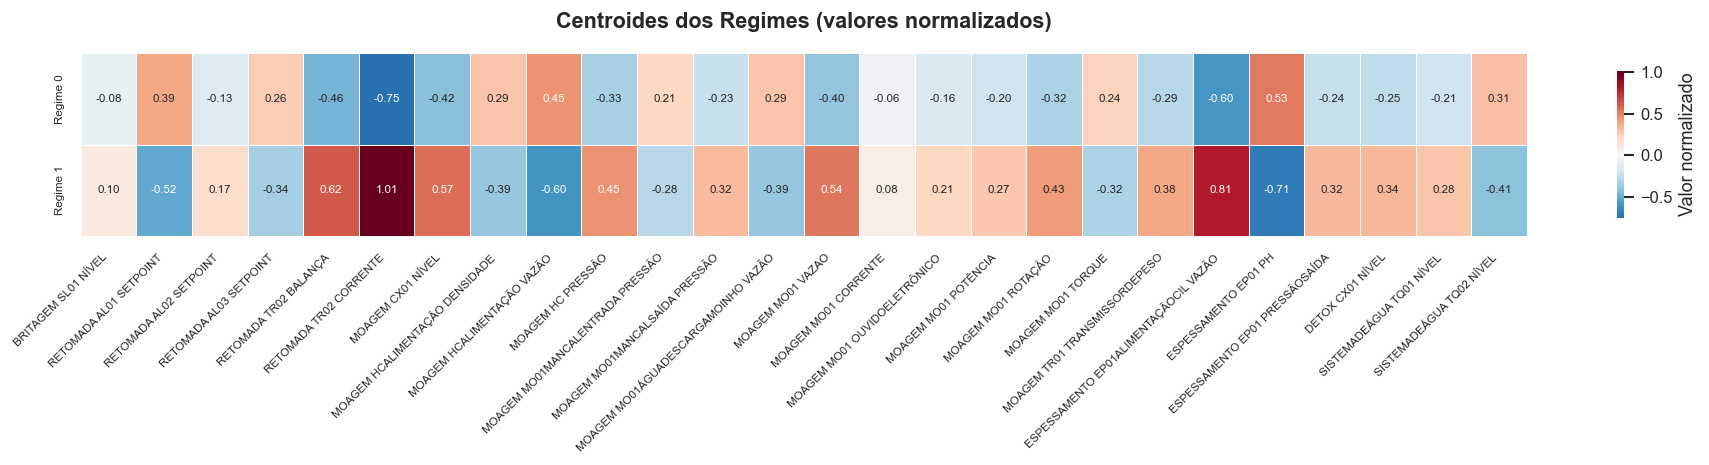

In [24]:
# --- 6.6 Heatmap dos centroides normalizados (todas as variáveis) ---
fig, ax = plt.subplots(figsize=(16, max(4, best_k * 1.2)))
labels_heat = [NOMES_CURTOS[c] for c in COLS_CLUSTER]
sns.heatmap(centroides_norm[COLS_CLUSTER].values, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.3, xticklabels=labels_heat,
            yticklabels=[f"Regime {r}" for r in range(best_k)],
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8, "label": "Valor normalizado"})
ax.set_title("Centroides dos Regimes (valores normalizados)", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(labelsize=7)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v1_06_heatmap_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "heatmap_centroides", fig, "S1c_v1_06_heatmap_centroides.png")
plt.show()

## 7 - Salvamento dos Resultados

**Objetivo:** Persistir todos os resultados do clustering para consumo pelo dashboard e
rastreabilidade entre versões do pipeline.

**Armazenamento local (parquet/CSV):**
- `dados_com_clusters_v1.parquet`: dataset completo com coluna `regime` adicionada
- `metricas_clustering_v1.csv`: métricas de validação de todos os algoritmos/k
- `regimes_v1.csv`: estatísticas descritivas de cada regime

**Armazenamento no banco (PostgreSQL):**
- `s1c_v1_metricas_clustering`: métricas para o dashboard
- `s1c_v1_regimes`: caracterização dos regimes
- `s1c_v1_regime_centroides`: centroides em formato longo (regime x variável x valor)

**Importante:** Os dados NÃO são salvos na tabela `dados_com_clusters` (reservada para a
versão final v3). Cada versão usa stage próprio (`s1c_v1`) para evitar sobrescrever resultados.

In [25]:
# ==============================================================================
# Salvar resultados: parquet local + métricas/imagens no banco
# ==============================================================================
print("\nSalvando resultados...")

# Preparar métricas de validação (todos os algoritmos/k avaliados)
df_metricas = pd.DataFrame([{
    "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
    "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
    "calinski_harabasz": r["calinski_harabasz"], "inertia": r["inertia"],
    "bic": r["bic"], "selecionado": r["selecionado"],
} for r in resultados])

# Salvar métricas em CSV para comparação entre versões
df_metricas.to_csv(DATA_PROC / "metricas_clustering_v1.csv", index=False)
df_regimes.to_csv(DATA_PROC / "regimes_v1.csv", index=False)
print(f"  Métricas CSV: {DATA_PROC / 'metricas_clustering_v1.csv'}")
print(f"  Regimes CSV: {DATA_PROC / 'regimes_v1.csv'}")

# ── Salvar log completo de TODOS os testes (KMeans + DBSCAN + GMM) ──
todos_testes = []
# KMeans e GMM (já em resultados)
for r in resultados:
    todos_testes.append({
        "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
        "calinski_harabasz": r["calinski_harabasz"],
        "inertia": r["inertia"], "bic": r["bic"],
        "eps": None, "min_samples": None, "pct_noise": None,
        "selecionado": r["selecionado"],
    })
# DBSCAN sweep (todas as combinações)
for r in dbscan_results:
    todos_testes.append({
        "algoritmo": "DBSCAN", "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": None,
        "calinski_harabasz": None,
        "inertia": None, "bic": None,
        "eps": r["eps"], "min_samples": r["min_samples"],
        "pct_noise": r["pct_noise"],
        "selecionado": False,
    })
df_todos_testes = pd.DataFrame(todos_testes)
df_todos_testes.to_csv(DATA_PROC / "todos_testes_clustering_v1.csv", index=False)
salvar_dataframe(df_todos_testes, "s1c_v1_todos_testes", modo="replace")
print(f"  Todos os testes: {len(df_todos_testes)} registros -> s1c_v1_todos_testes")

# Salvar métricas e regimes no banco com stage específico (não sobrescreve v3)
salvar_dataframe(df_metricas, "s1c_v1_metricas_clustering")
salvar_dataframe(df_regimes, "s1c_v1_regimes")
salvar_dataframe(df_centroides, "s1c_v1_regime_centroides")
print(f"  Banco: s1c_v1_metricas_clustering, s1c_v1_regimes, s1c_v1_regime_centroides")

# Construir dataset completo com coluna regime (NaN para registros excluídos na limpeza)
df_output = df.reset_index()
df_output["regime"] = np.nan
# Atribuir regimes alinhando por índice (não por posição) para evitar mismatch
regime_series = df_clean_regime["regime"].rename("_regime_tmp")
df_output = df_output.merge(
    regime_series.reset_index().rename(columns={regime_series.index.name or "index": "Timestamp", "_regime_tmp": "regime_aligned"}),
    on="Timestamp", how="left"
)
df_output["regime"] = df_output["regime_aligned"].astype("Int64")
df_output = df_output.drop(columns=["regime_aligned"])

# Salvar parquet versionado (NÃO salva em dados_com_clusters para não sobrescrever v3)
df_output.to_parquet(DATA_PROC / "dados_com_clusters_v1.parquet", index=False)
print(f"  Parquet: {DATA_PROC / 'dados_com_clusters_v1.parquet'} ({len(df_output):,} linhas)")

# 3. s1c_v1_dados_com_clusters — dataset completo usado no clustering (rastreabilidade)
salvar_dataframe(df_output, "s1c_v1_dados_com_clusters", modo="replace")

# Liberar memória da GPU (se disponível)
del X_tensor
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("  Memória liberada")


Salvando resultados...
  Métricas CSV: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\metricas_clustering_v1.csv
  Regimes CSV: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\regimes_v1.csv
[db_utils] 15 linhas salvas em otimizar_moagem_aura.s1c_v1_todos_testes
  Todos os testes: 15 registros -> s1c_v1_todos_testes
[db_utils] 15 linhas salvas em otimizar_moagem_aura.s1c_v1_metricas_clustering
[db_utils] 2 linhas salvas em otimizar_moagem_aura.s1c_v1_regimes
[db_utils] 52 linhas salvas em otimizar_moagem_aura.s1c_v1_regime_centroides
  Banco: s1c_v1_metricas_clustering, s1c_v1_regimes, s1c_v1_regime_centroides
  Parquet: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\dados_com_clusters_v1.parquet (632,985 linhas)
[db_utils] s1c_v1_dados_com_clusters: 500,000 / 632,985 (79.0%)
[db_utils] s1c_v1_dados_com_clusters: 632,985 / 632,985 (100.0%)
[db_utils] 632,985 linhas salvas em otimizar_moagem_aura.s1c_v1_dados_com_clusters
  Memória liberada


## 8 - Resumo da Execução

**Objetivo:** Exibir um resumo consolidado do pipeline de clustering (v1): modelo
selecionado, métricas de validação, variância explicada pelo PCA e distribuição dos regimes
identificados. Este resumo serve como referência rápida para comparação entre versões.

In [26]:
# 8. RESUMO
elapsed = time.time() - t0
print("\n" + "=" * 60)
print("  RESUMO DO CLUSTERING (S1c)")
print("=" * 60)
print(f"  Tempo total:           {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"  Algoritmos avaliados:  KMeans, DBSCAN, GMM")
print(f"  Algoritmo selecionado: {best_algo} k={best_k}")
print(f"  Silhouette:            {best['silhouette']}")
print(f"  Davies-Bouldin:        {best['davies_bouldin']}")
print(f"  Calinski-Harabasz:     {best['calinski_harabasz']}")
print(f"  Variancia PCA (2D):    {sum(var_explained[:2])*100:.1f}%")
print(f"  Regimes:")
for _, row in df_regimes.iterrows():
    print(f"    Regime {row['regime']}: {row['n_samples']:>8,} ({row['percentual']:5.1f}%)  "
          f"TPH={row['tph_medio']:.1f} +/- {row['tph_std']:.1f}")
print(f"  Salvos: metricas={len(df_metricas)}, regimes={len(df_regimes)}, "
      f"centroides={len(df_centroides)}, dados={len(df_output):,}, figuras=6")
print("=" * 60)


  RESUMO DO CLUSTERING (S1c)
  Tempo total:           4753s (79.2 min)
  Algoritmos avaliados:  KMeans, DBSCAN, GMM
  Algoritmo selecionado: KMeans k=2
  Silhouette:            0.1608
  Davies-Bouldin:        2.1965
  Calinski-Harabasz:     122690.9
  Variancia PCA (2D):    31.9%
  Regimes:
    Regime 0.0: 362,904.0 ( 57.3%)  TPH=241.2 +/- 33.6
    Regime 1.0: 270,081.0 ( 42.7%)  TPH=286.2 +/- 36.5
  Salvos: metricas=15, regimes=2, centroides=52, dados=632,985, figuras=6


## 9 - Exportação HTML

**Objetivo:** Exportar o notebook completo para HTML (sem código, apenas outputs) para
documentação e compartilhamento dos resultados com a equipe.

In [27]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs, sem código)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# Salvar checkpoint do notebook antes de exportar
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\01_sprint1\clusters\c_clustering_regimes_v1.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

# Ler o notebook e converter para HTML (excluindo células de código)
with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "CLUSTER_c_clustering_regimes_v1.html"
_out_path.write_text(_html_body, encoding="utf-8")
print(f"HTML exportado: {_out_path}")

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\CLUSTER_c_clustering_regimes_v1.html
